# Fine-Tune Qwen2-VL-2B dengan QLoRA

**Objective:** Melatih Vision-Language Model menggunakan QLoRA (Low-Rank Adaptation + 4-bit Quantization) untuk analisis diagnostik Visual XAI. Dataset menggunakan image-level split yang sama dengan referensi sebelumnya untuk memastikan validitas kontrol eksperimen.

In [1]:
%%capture
!pip install transformers>=4.45.0 peft>=0.12.0 accelerate bitsandbytes trl
!pip install qwen-vl-utils pillow rouge-score bert-score
!pip install flash-attn --no-build-isolation 2>/dev/null || echo "flash-attn not available, using eager attention"
print("Dependencies installed")

In [1]:
import os
import json
import torch
import random
import numpy as np
from PIL import Image
from datetime import datetime

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch: 2.5.1+cu124
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.0 GB


## Configuration
Pengaturan environment, path dataset, dan hyperparameter pelatihan. Argument `USE_SAME_SPLIT_AS_QLORA` dipastikan `True` agar perbandingan performa akurat.

In [2]:
import os

IS_KAGGLE = False  # Set to True jika dijalankan di Kaggle

if IS_KAGGLE:
    DATASET_ROOT = "/kaggle/input/datasets/stevenalvinchristian/vlm-autonomouscar-dataset/vlm_dataset"
    DATASET_PATH = os.path.join(DATASET_ROOT, "vlm_dataset.jsonl")
    PANELS_DIR = os.path.join(DATASET_ROOT, "panels")
    OUTPUT_DIR = "/kaggle/working/qwen_vlm_finetuned"
else:
    DATASET_PATH = os.path.join("vlm_dataset", "vlm_dataset.jsonl")
    PANELS_DIR = os.path.join("vlm_dataset", "panels")
    OUTPUT_DIR = "qwen_vlm_finetuned"
    QLORA_SPLIT_INFO = os.path.join("qlora_split_info.json")

MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

# Dataset Sampling
MAX_DATASET_SIZE = 4000
TEST_RATIO = 0.2
USE_SAME_SPLIT_AS_QLORA = True

# LoRA Parameters
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
USE_DORA = False

# Training Parameters
NUM_EPOCHS = 2
BATCH_SIZE = 2 if IS_KAGGLE else 1
GRAD_ACCUM = 4 if IS_KAGGLE else 16
LEARNING_RATE = 1e-4
MAX_SEQ_LENGTH = 1280
WARMUP_RATIO = 0.1
IMAGE_SIZE = 448 if IS_KAGGLE else 384
 
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Model: {MODEL_NAME}")
print(f"Adapter: {'DoRA' if USE_DORA else 'LoRA'}")
print(f"LoRA r={LORA_R}, alpha={LORA_ALPHA}")
print(f"Output: {OUTPUT_DIR}")

Model: Qwen/Qwen2-VL-2B-Instruct
Adapter: LoRA
LoRA r=8, alpha=16
Output: qwen_vlm_finetuned


## Load & Prepare Dataset
Logika pemrosesan data, menangani pembersihan input dan melakukan partisi training/testing berdasar image-level untuk mencegah data leakage.

In [3]:
import pandas as pd
from collections import defaultdict
import gc

dataset_raw = []
skipped = 0
parse_fail = 0
missing_images = 0
first_missing_path = ""

with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        entry = json.loads(line)
        out = entry.get('output', '')
        if out.startswith('[API_ERROR]') or out == '[EMPTY_RESPONSE]' or not out.strip():
            skipped += 1
            continue
        
        img_name = entry.get('image', '').strip()
        img_path = os.path.join(PANELS_DIR, img_name)
        
        if not os.path.exists(img_path):
            missing_images += 1
            skipped += 1
            if missing_images == 1:
                first_missing_path = img_path
            continue
            
        try:
            input_obj = json.loads(entry.get('input', '{}'))
        except Exception:
            parse_fail += 1
            input_obj = {}
            
        entry['image_path'] = img_path
        entry['_input_obj'] = input_obj
        dataset_raw.append(entry)

print(f"Loaded: {len(dataset_raw)} entries (skipped {skipped} total, missing_images {missing_images}, parse_fail {parse_fail})")

if len(dataset_raw) == 0:
    print(f"\n--- 🚨 DEBUGGING INFO 🚨 ---")
    print(f"Path dataset  : {DATASET_PATH} (Exists: {os.path.exists(DATASET_PATH)})")
    print(f"Path panels   : {PANELS_DIR} (Exists: {os.path.exists(PANELS_DIR)})")
    if missing_images > 0:
        print(f"Contoh path gambar yang tidak ditemukan: {first_missing_path}")
        if os.path.exists(PANELS_DIR):
            files_in_dir = os.listdir(PANELS_DIR)
            print(f"Isi folder PANELS_DIR (5 files): {files_in_dir[:5]}")
    print("----------------------------\n")
    raise ValueError("Dataset is empty. 100% gambar gagal ditemukan. Cek PANELS_DIR.")

random.seed(SEED)

# Pengelompokan data logis berdasarkan Image
by_image = defaultdict(list)
for e in dataset_raw:
    by_image[e.get('image', '')].append(e)

image_keys = list(by_image.keys())
random.shuffle(image_keys)

selected_images = []
total_entries = 0
for img_key in image_keys:
    if total_entries >= MAX_DATASET_SIZE:
        break
    selected_images.append(img_key)
    total_entries += len(by_image[img_key])

# Memory Optimization: Rebuild array efisien menggunakan generator & bersihkan memory lama
dataset_kept = []
for img in selected_images:
    dataset_kept.extend(by_image[img])

# Kosongkan memory besar yang tidak terpakai
del dataset_raw
del by_image
gc.collect()

dataset_raw = dataset_kept

# Data Split Control
if USE_SAME_SPLIT_AS_QLORA and os.path.exists(QLORA_SPLIT_INFO):
    print(f"Loading consistent split definitions from: {QLORA_SPLIT_INFO}")
    with open(QLORA_SPLIT_INFO, 'r') as f:
        split_info = json.load(f)
    
    test_image_set = set(split_info['test_images'])
    train_image_set = set(selected_images) - test_image_set
else:
    print("Generating randomized data split...")
    random.shuffle(selected_images)
    n_test_images = max(1, int(len(selected_images) * TEST_RATIO))
    test_image_set = set(selected_images[:n_test_images])
    train_image_set = set(selected_images[n_test_images:])

assert len(train_image_set & test_image_set) == 0, "Data leakage detected: Image overlap in sets."

test_data = [e for e in dataset_raw if e.get('image', '') in test_image_set]
train_data = [e for e in dataset_raw if e.get('image', '') in train_image_set]

# Clear the temporary source array to save RAM
del dataset_raw
gc.collect()

train_types = defaultdict(int)
test_types = defaultdict(int)
for e in train_data:
    train_types[e['_input_obj'].get('object_type', '?')] += 1
for e in test_data:
    test_types[e['_input_obj'].get('object_type', '?')] += 1

print(f"Train set: {len(train_data)} entries across {len(train_image_set)} images")
print(f"Test set: {len(test_data)} entries across {len(test_image_set)} images")
total_split = len(train_data) + len(test_data)
actual_ratio = (len(test_data) / total_split * 100) if total_split > 0 else 0
print(f"Test Ratio: {actual_ratio:.1f}%")

Loaded: 4098 entries (skipped 3332 total, missing_images 3332, parse_fail 0)
Generating randomized data split...
Train set: 3228 entries across 392 images
Test set: 774 entries across 98 images
Test Ratio: 19.3%


## Load Qwen2-VL-2B & Adapter
Memuat arsitektur model utama yang dikonfigurasi dengan kuantisasi memori 4-bit (NF4) serta PEFT LoraConfig.

In [4]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch
import gc

USE_BF16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print(f"Precision format: {'bf16' if USE_BF16 else 'fp16'}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

# Bersihkan memory sekali lagi
gc.collect()
torch.cuda.empty_cache()

# Load processor lebih dulu agar beban memori tidak bersamaan dengan model
processor = AutoProcessor.from_pretrained(MODEL_NAME)

# Load model dengan device_map={"": 0} untuk memaksa masuk ke GPU. 
# device_map="auto" di Kaggle sering salah kalkulasi dan mencoba menaruh layer di CPU RAM yang menyebabkan OOM/Kernel Crash.
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    torch_dtype=COMPUTE_DTYPE,
    attn_implementation="sdpa",
)

model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()
model.config.use_cache = False

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type="CAUSAL_LM",
    use_dora=USE_DORA,
)
model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"Total Parameters: {total:,}")

/home/lenovo/miniconda3/envs/qwen_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Precision format: bf16


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 729/729 [00:08<00:00, 86.75it/s]  


Trainable Parameters: 9,232,384 (0.75%)
Total Parameters: 1,231,507,968


## Custom Data Collator
Konversi dan pipeline data input untuk memfasilitasi VLM format input (Image + Teks instruksional) dalam batch tensor.

In [19]:
from torch.utils.data import Dataset as TorchDataset

class XAIDiagnosticDataset(TorchDataset):
    def __init__(self, data, processor, image_size=384, max_length=1024):
        self.data = data
        self.processor = processor
        self.image_size = image_size
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        image = Image.open(entry['image_path']).convert('RGB')
        image = image.resize((self.image_size, self.image_size))
        
        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": entry['instruction'] + "\n" + entry['input']}
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": entry['output']}
            ]}
        ]
        
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(
            text=[text], images=[image],
            return_tensors="pt", padding=True,
            truncation=True, max_length=self.max_length
        )
        
        input_ids = inputs["input_ids"].squeeze(0)
        labels = input_ids.clone()
        
        assistant_token = self.processor.tokenizer.encode("assistant", add_special_tokens=False)
        for i in range(len(input_ids) - len(assistant_token)):
            if input_ids[i:i+len(assistant_token)].tolist() == assistant_token:
                labels[:i+len(assistant_token)] = -100
                break
        
        result = {
            "input_ids": input_ids,
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "pixel_values": inputs.get("pixel_values", torch.zeros(1)),
            "image_grid_thw": inputs.get("image_grid_thw", None),
            "labels": labels,
        }
        
        if "mm_token_type_ids" in inputs:
            result["mm_token_type_ids"] = inputs["mm_token_type_ids"].squeeze(0)
            
        return result

train_dataset = XAIDiagnosticDataset(train_data, processor, IMAGE_SIZE, MAX_SEQ_LENGTH)
print(f"Train dataset ready: {len(train_dataset)} samples")

sample = train_dataset[0]
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  labels shape: {sample['labels'].shape}")
if 'pixel_values' in sample and sample['pixel_values'] is not None:
    print(f"  pixel_values shape: {sample['pixel_values'].shape}")
if 'image_grid_thw' in sample and sample['image_grid_thw'] is not None:
    print(f"  image_grid_thw shape: {sample['image_grid_thw'].shape}")
if 'mm_token_type_ids' in sample and sample['mm_token_type_ids'] is not None:
    print(f"  mm_token_type_ids shape: {sample['mm_token_type_ids'].shape}")

Train dataset ready: 3228 samples
  input_ids shape: torch.Size([970])
  labels shape: torch.Size([970])
  pixel_values shape: torch.Size([784, 1176])
  image_grid_thw shape: torch.Size([1, 3])
  mm_token_type_ids shape: torch.Size([970])


In [20]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    out = {}
    input_ids = [item['input_ids'] for item in batch]
    labels = [item['labels'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    
    pad_token_id = processor.tokenizer.pad_token_id if processor.tokenizer.pad_token_id is not None else 0
    
    out['input_ids'] = pad_sequence(input_ids, batch_first=True, padding_value=pad_token_id)
    out['labels'] = pad_sequence(labels, batch_first=True, padding_value=-100)
    out['attention_mask'] = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    
    if 'pixel_values' in batch and batch['pixel_values'] is not None:
        out['pixel_values'] = torch.cat([item['pixel_values'] for item in batch], dim=0)
        
    if 'image_grid_thw' in batch and batch['image_grid_thw'] is not None:
        out['image_grid_thw'] = torch.cat([item['image_grid_thw'] for item in batch], dim=0)
        
    if 'mm_token_type_ids' in batch and batch['mm_token_type_ids'] is not None:
        mm_token_type_ids = [item['mm_token_type_ids'] for item in batch]
        out['mm_token_type_ids'] = pad_sequence(mm_token_type_ids, batch_first=True, padding_value=0)
        
    return out

## Training Process
Inisiasi loop Hugging Face Trainer dengan memori VRAM yang dibatasi oleh Gradient Accumulation.

In [6]:
from transformers import TrainingArguments, Trainer

total_steps = (len(train_dataset) * NUM_EPOCHS) // (BATCH_SIZE * GRAD_ACCUM)
calculated_warmup_steps = int(total_steps * WARMUP_RATIO)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=calculated_warmup_steps,
    fp16=not USE_BF16,
    bf16=USE_BF16,
    logging_steps=10,
    save_strategy="epoch",
    optim="paged_adamw_8bit",
    weight_decay=0.01,
    max_grad_norm=0.3,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    logging_nan_inf_filter=False,
    report_to="none",
    seed=SEED,
)

def collate_fn(batch):
    item = batch[0]
    out = {}
    for k, v in item.items():
        if v is None:
            continue
        if isinstance(v, torch.Tensor):
            if k == "image_grid_thw":
                out[k] = v.unsqueeze(0) if v.dim() == 1 else v
            else:
                out[k] = v.unsqueeze(0)
        else:
            out[k] = v
    return out

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=collate_fn,
    )

import time
start = time.time()
stats = trainer.train()
elapsed = time.time() - start
print(f"Training runtime: {elapsed/60:.1f} minutes")
print(f"Final training loss: {stats.training_loss:.4f}")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
10,1.793772
20,1.712071
30,1.540181
40,1.403405
50,1.253718
60,1.218482
70,1.144186
80,1.090447
90,1.066089
100,1.027203


Training runtime: 702.3 minutes
Final training loss: 1.0161


## Evaluation
Menghitung performa model menggunakan metrik ROUGE, BERTScore, dan rasio format output.

In [7]:
import gc
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
from qwen_vl_utils import process_vision_info

nltk.download('punkt_tab', quiet=True)

# Free memory before evaluation
if 'train_dataset' in globals(): del train_dataset
if 'trainer' in globals(): del trainer
gc.collect()
torch.cuda.empty_cache()

def generate_vlm_response(model, processor, image_path, instruction, input_text, max_tokens=512):
    """Generate a diagnostic response for a single test sample."""
    try:
        image = Image.open(image_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        messages = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": instruction + "\n" + input_text}
        ]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_tokens, temperature=0.3, do_sample=True)
        result = processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

        del inputs, out, image, messages
        return result
    except Exception as e:
        return f"[ERROR] {str(e)}"

def compute_bleu(reference, prediction):
    """Sentence-level BLEU-4 with smoothing for short sequences."""
    ref_tokens = nltk.word_tokenize(reference.lower())
    pred_tokens = nltk.word_tokenize(prediction.lower())
    smoothie = SmoothingFunction().method1
    try:
        return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)
    except:
        return 0.0

# --- Evaluation Loop with Per-Sample Metrics ---
print("Generating predictions on test set...")
EVAL_SAMPLES = min(50, len(test_data))
scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
EXPECTED_SECTIONS = ["Attention Pattern", "Spurious Correlation", "Failure Diagnosis", "Risk Assessment"]

predictions_data = []
for i, entry in enumerate(test_data[:EVAL_SAMPLES]):
    resp = generate_vlm_response(model, processor, entry['image_path'], entry['instruction'], entry['input'])
    ref = entry['output']

    # Per-sample ROUGE
    s = scorer_obj.score(ref, resp)
    # Per-sample BLEU
    bleu = compute_bleu(ref, resp)
    # Per-sample Format Compliance
    fmt = sum(1 for sec in EXPECTED_SECTIONS if sec.lower() in resp.lower()) / len(EXPECTED_SECTIONS)

    predictions_data.append({
        'image': entry.get('image', ''),
        'object_type': entry['_input_obj'].get('object_type', ''),
        'object_class': entry['_input_obj'].get('object_class', ''),
        'risk_tier': entry['_input_obj'].get('risk_tier', ''),
        'instruction': entry['instruction'],
        'reference': ref,
        'prediction': resp,
        'rouge1': round(s['rouge1'].fmeasure, 4),
        'rouge2': round(s['rouge2'].fmeasure, 4),
        'rougeL': round(s['rougeL'].fmeasure, 4),
        'bleu': round(bleu, 4),
        'format_compliance': round(fmt, 4),
    })

    if i < 2:
        print(f"  #{i+1}: {resp[:150]}...")
    if (i + 1) % 10 == 0:
        print(f"  Progress: {i+1}/{EVAL_SAMPLES}")
        gc.collect()
        torch.cuda.empty_cache()

# BERTScore (batched for efficiency)
after_preds = [p['prediction'] for p in predictions_data]
references_list = [p['reference'] for p in predictions_data]
P, R, F1 = bert_score_fn(after_preds, references_list, lang="en", verbose=False)

for i, p in enumerate(predictions_data):
    p['bert_score_f1'] = round(F1[i].item(), 4)

# --- Aggregated Metrics ---
rouge_avg = {k: round(np.mean([p[k] for p in predictions_data]), 4) for k in ['rouge1', 'rouge2', 'rougeL']}
bleu_avg = round(np.mean([p['bleu'] for p in predictions_data]), 4)
bert_f1 = round(F1.mean().item(), 4)
fmt_compliance = round(np.mean([p['format_compliance'] for p in predictions_data]) * 100, 1)
error_count = sum(1 for p in predictions_data if p['prediction'].startswith('[ERROR]'))

METHOD = 'QDoRA' if USE_DORA else 'QLoRA'
print("\n" + "=" * 60)
print(f"  {METHOD} EVALUATION RESULTS")
print("=" * 60)
print(f"  ROUGE-1:          {rouge_avg['rouge1']}")
print(f"  ROUGE-2:          {rouge_avg['rouge2']}")
print(f"  ROUGE-L:          {rouge_avg['rougeL']}")
print(f"  BLEU:             {bleu_avg}")
print(f"  BERTScore F1:     {bert_f1}")
print(f"  Format Compliance:{fmt_compliance}%")
print(f"  Errors:           {error_count}/{EVAL_SAMPLES}")
try:
    print(f"  Training Time:    {elapsed/60:.1f} min ({elapsed/3600:.1f} hours)")
    print(f"  Final Loss:       {stats.training_loss:.4f}")
except: pass
print(f"  Trainable Params: {trainable:,}")

Generating predictions on test set...
  #1: - The pedestrian detection is a True Positive with high IoU, indicating good localization.
- The attention heatmap shows strong focus on the pedestria...
  #2: This case study examines a critical failure in object detection, specifically the missed detection of a cyclist, classified as a False Negative (FN). ...
  Progress: 10/50
  Progress: 20/50
  Progress: 30/50
  Progress: 40/50
  Progress: 50/50


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3458.97it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  QLoRA EVALUATION RESULTS
  ROUGE-1:          0.5557
  ROUGE-2:          0.256
  ROUGE-L:          0.2933
  BLEU:             0.1473
  BERTScore F1:     0.8853
  Format Compliance:23.5%
  Errors:           0/50
  Trainable Params: 9,232,384


In [8]:
# --- Save Per-Sample Predictions ---
per_sample_output = {
    'method': METHOD,
    'model': MODEL_NAME,
    'eval_samples': EVAL_SAMPLES,
    'aggregated': {
        'rouge': rouge_avg,
        'bleu': bleu_avg,
        'bert_score_f1': bert_f1,
        'format_compliance': fmt_compliance,
        'error_count': error_count,
    },
    'predictions': predictions_data,
}
try:
    per_sample_output['aggregated']['training_time_min'] = round(elapsed / 60, 1)
    per_sample_output['aggregated']['final_loss'] = round(stats.training_loss, 4)
except:
    pass
per_sample_output['aggregated']['trainable_params'] = trainable

with open(os.path.join(OUTPUT_DIR, 'per_sample_predictions.json'), 'w', encoding='utf-8') as f:
    json.dump(per_sample_output, f, ensure_ascii=False, indent=2)
print(f"Per-sample predictions saved: {OUTPUT_DIR}/per_sample_predictions.json")

# Backward-compatible aggregated results
results = {
    'method': METHOD,
    'rouge': rouge_avg,
    'bleu': bleu_avg,
    'bert_score': bert_f1,
    'format_compliance': fmt_compliance,
    'trainable_params': trainable,
    'error_count': error_count,
    'eval_samples': EVAL_SAMPLES,
}
try:
    results['training_time_min'] = round(elapsed / 60, 1)
    results['final_loss'] = round(stats.training_loss, 4)
except: pass

with open(os.path.join(OUTPUT_DIR, 'vlm_eval_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f"Aggregated results saved: {OUTPUT_DIR}/vlm_eval_results.json")

Per-sample predictions saved: qwen_vlm_finetuned/per_sample_predictions.json
Aggregated results saved: qwen_vlm_finetuned/vlm_eval_results.json


## Visualization

### Aggregated Metrics & Per-Sample Distribution

Left panel: bar chart of mean scores across all evaluated samples.
Right panel: box plot showing the spread (median, IQR, outliers) of per-sample scores —
reveals whether the model is *consistently* good or has high variance.

/tmp/ipykernel_221296/3697007980.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data.values(), labels=box_data.keys(), patch_artist=True,


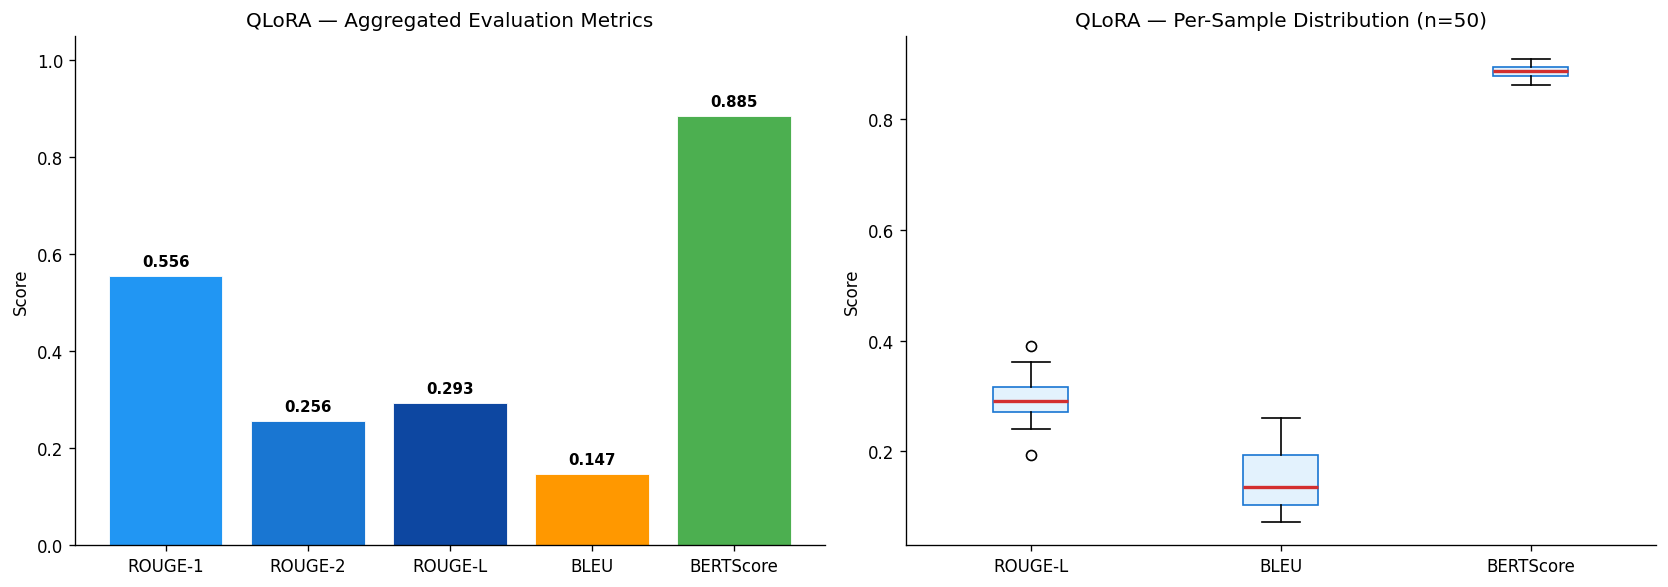

Plot saved: qwen_vlm_finetuned/qlora_metrics.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Aggregated metric bar chart
metric_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'BERTScore']
metric_vals = [rouge_avg['rouge1'], rouge_avg['rouge2'], rouge_avg['rougeL'], bleu_avg, bert_f1]
colors = ['#2196F3', '#1976D2', '#0D47A1', '#FF9800', '#4CAF50']

bars = axes[0].bar(metric_names, metric_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title(f'{METHOD} — Aggregated Evaluation Metrics')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Right: Per-sample score distribution (box plot)
box_data = {
    'ROUGE-L': [p['rougeL'] for p in predictions_data],
    'BLEU': [p['bleu'] for p in predictions_data],
    'BERTScore': [p['bert_score_f1'] for p in predictions_data],
}
bp = axes[1].boxplot(box_data.values(), labels=box_data.keys(), patch_artist=True,
                      boxprops=dict(facecolor='#E3F2FD', edgecolor='#1976D2'),
                      medianprops=dict(color='#D32F2F', linewidth=2))
axes[1].set_ylabel('Score')
axes[1].set_title(f'{METHOD} — Per-Sample Distribution (n={EVAL_SAMPLES})')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{METHOD.lower()}_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved: {OUTPUT_DIR}/{METHOD.lower()}_metrics.png")

### Example Predictions

Showing 3 sample predictions to qualitatively assess output quality, diagnostic structure,
and alignment with reference text.

In [10]:
# --- Example Predictions ---
print("=" * 80)
print(f"SAMPLE PREDICTIONS ({METHOD})")
print("=" * 80)

for idx, p in enumerate(predictions_data[:3]):
    print(f"\n{chr(9472) * 80}")
    print(f"Example {idx+1}: {p['object_class'].upper()} ({p['object_type']}) | Risk: {p['risk_tier']} | Image: {p['image']}")
    print(f"Scores: ROUGE-L={p['rougeL']:.3f} | BLEU={p['bleu']:.3f} | BERTScore={p['bert_score_f1']:.3f} | Format={p['format_compliance']:.0%}")
    print(f"\nReference (first 300 chars):")
    print(f"  {p['reference'][:300]}...")
    print(f"\nPrediction (first 300 chars):")
    print(f"  {p['prediction'][:300]}...")

SAMPLE PREDICTIONS (QLoRA)

────────────────────────────────────────────────────────────────────────────────
Example 1: PEDESTRIAN (TP) | Risk: CRITICAL | Image: 0151_3panel.jpg
Scores: ROUGE-L=0.291 | BLEU=0.137 | BERTScore=0.883 | Format=0%

Reference (first 300 chars):
  OBSERVATION: The heatmap shows significant attention focused on the detected pedestrian. The highest attention areas, indicated by red and yellow, are concentrated on the body of the pedestrian. There is minimal heat spreading to the background or surrounding objects.

EVIDENCE: The `focus_score` of...

Prediction (first 300 chars):
  - The pedestrian detection is a True Positive with high IoU, indicating good localization.
- The attention heatmap shows strong focus on the pedestrian, with a high `focus_score` and `attention_concentration`.
- The `background_leakage` is very low, suggesting the model is not being distracted by ir...

────────────────────────────────────────────────────────────────────────────────
Ex

## Save Artifacts
Penyimpanan target model weight beserta metadata metrik dan konfigurasi evaluasi dalam environment persisten.

In [18]:
model.save_pretrained(os.path.join(OUTPUT_DIR, "lora_adapter"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "lora_adapter"))

with open(os.path.join(OUTPUT_DIR, "split_info.json"), 'w') as f:
    json.dump({
        'test_images': list(set(e.get('image', '') for e in test_data)),
        'train_count': len(train_data),
        'test_count': len(test_data),
        'method': 'QLoRA',
        'same_split_as_qlora': USE_SAME_SPLIT_AS_QLORA,
    }, f, indent=2)

config = {
    'method': 'QLoRA',
    'model': MODEL_NAME,
    'lora_r': LORA_R,
    'lora_alpha': LORA_ALPHA,
    'lora_dropout': LORA_DROPOUT,
    'use_dora': USE_DORA,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'grad_accum': GRAD_ACCUM,
    'effective_batch_size': BATCH_SIZE * GRAD_ACCUM,
    'learning_rate': LEARNING_RATE,
    'max_seq_length': MAX_SEQ_LENGTH,
    'image_size': IMAGE_SIZE,
    'seed': SEED,
}
with open(os.path.join(OUTPUT_DIR, "config.json"), 'w') as f:
    json.dump(config, f, indent=2)

print("Export verification:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for fn in files:
        path = os.path.join(root, fn)
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f"  {os.path.relpath(path, OUTPUT_DIR)}: {size_mb:.1f} MB")

Export verification:
  per_sample_predictions.json: 0.1 MB
  config.json: 0.0 MB
  qlora_metrics.png: 0.0 MB
  split_info.json: 0.0 MB
  vlm_eval_results.json: 0.0 MB
  lora_adapter/tokenizer_config.json: 0.0 MB
  lora_adapter/README.md: 0.0 MB
  lora_adapter/tokenizer.json: 10.9 MB
  lora_adapter/adapter_config.json: 0.0 MB
  lora_adapter/adapter_model.safetensors: 35.3 MB
  lora_adapter/chat_template.jinja: 0.0 MB
  lora_adapter/processor_config.json: 0.0 MB
  checkpoint-202/trainer_state.json: 0.0 MB
  checkpoint-202/optimizer.pt: 18.9 MB
  checkpoint-202/README.md: 0.0 MB
  checkpoint-202/adapter_config.json: 0.0 MB
  checkpoint-202/scheduler.pt: 0.0 MB
  checkpoint-202/adapter_model.safetensors: 35.3 MB
  checkpoint-202/training_args.bin: 0.0 MB
  checkpoint-202/rng_state.pth: 0.0 MB
  checkpoint-404/trainer_state.json: 0.0 MB
  checkpoint-404/optimizer.pt: 18.9 MB
  checkpoint-404/README.md: 0.0 MB
  checkpoint-404/adapter_config.json: 0.0 MB
  checkpoint-404/scheduler.pt: 0.0 MB

In [ ]:
import os
import json
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel
from qwen_vl_utils import process_vision_info
from PIL import Image

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model_name = "Qwen/Qwen2-VL-2B-Instruct"
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    attn_implementation="sdpa"
)

adapter_path = "qwen_vlm_finetuned/lora_adapter"
processor = AutoProcessor.from_pretrained(adapter_path)

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

split_info_path = "qwen_vlm_finetuned/split_info.json"
with open(split_info_path, 'r') as f:
    split_info = json.load(f)
    test_images = split_info.get("test_images", [])

panels_dir = "vlm_dataset/panels"
instruction = "Lakukan analisis diagnostik Visual XAI pada gambar ini."
results = []

for idx, img_name in enumerate(test_images):
    print(f"Memproses gambar {idx + 1} dari {len(test_images)}: {img_name}")
    img_path = os.path.join(panels_dir, img_name)
    
    if not os.path.exists(img_path):
        print(f"Gambar {img_name} tidak ditemukan, melewati...")
        continue
        
    try:
        image = Image.open(img_path).convert("RGB")
        image.thumbnail((512, 512)) 

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": instruction}
                ]
            }
        ]

        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)

        inputs = processor(
            text=[text_prompt],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=256,
                temperature=0.3,
                do_sample=True
            )

        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
        ]
        output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )
        
        results.append({
            "image": img_name,
            "prediction": output_text
        })
        
    except Exception as e:
        print(f"Terjadi kesalahan pada {img_name}: {e}")

output_path = "qwen_vlm_finetuned/batch_predictions.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Selesai! Hasil prediksi disimpan di {output_path}")

Loading weights: 100%|██████████| 729/729 [00:01<00:00, 407.49it/s] 


Memproses gambar 1 dari 98: 2163_3panel.jpg
Memproses gambar 2 dari 98: 0849_3panel.jpg
Memproses gambar 3 dari 98: 2175_3panel.jpg
Memproses gambar 4 dari 98: 0151_3panel.jpg
Memproses gambar 5 dari 98: 2132_3panel.jpg
Memproses gambar 6 dari 98: 0004_3panel.jpg
Memproses gambar 7 dari 98: 1751_3panel.jpg
Memproses gambar 8 dari 98: 0085_3panel.jpg
Memproses gambar 9 dari 98: 0417_3panel.jpg
Memproses gambar 10 dari 98: 0593_3panel.jpg
Memproses gambar 11 dari 98: 1304_3panel.jpg
Memproses gambar 12 dari 98: 2042_3panel.jpg
Memproses gambar 13 dari 98: 1742_3panel.jpg
Memproses gambar 14 dari 98: 2317_3panel.jpg
Memproses gambar 15 dari 98: 2272_3panel.jpg
Memproses gambar 16 dari 98: 1668_3panel.jpg
Memproses gambar 17 dari 98: 0631_3panel.jpg
Memproses gambar 18 dari 98: 1593_3panel.jpg
Memproses gambar 19 dari 98: 0995_3panel.jpg
Memproses gambar 20 dari 98: 1913_3panel.jpg
Memproses gambar 21 dari 98: 2031_3panel.jpg


KeyboardInterrupt: 